# installation

In [3]:
!pip install tensorflow keras

# Prerequisites

In [4]:
# Standard Data Science Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Deep Learning Libraries (Keras/TensorFlow)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Dropout, BatchNormalization, concatenate
from tensorflow.keras.optimizers import Adam

# Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve

# Downloads
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Set visualization style
sns.set(style='whitegrid')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


# Exploratory Data Analysis (EDA)

Missing values before drop:
 id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64


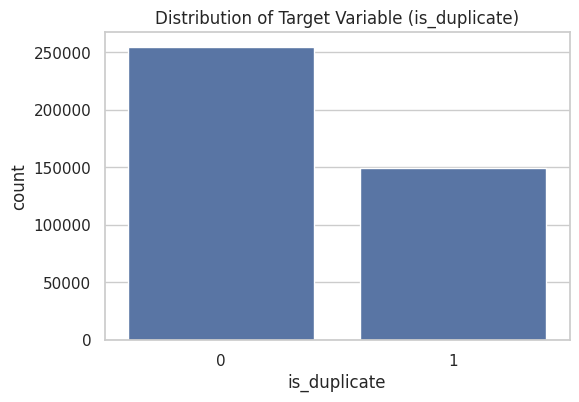

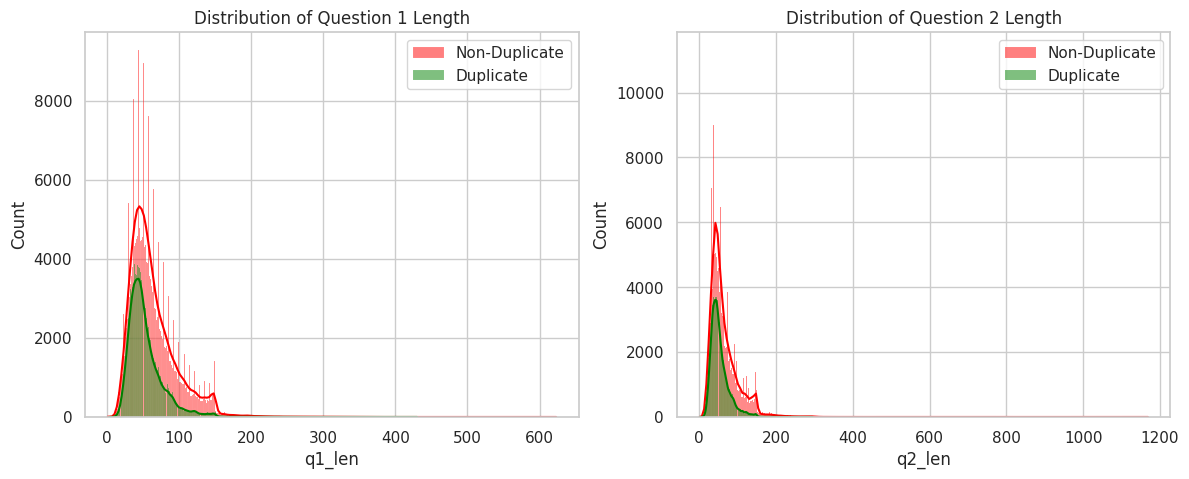

              q1_len         q2_len
count  404348.000000  404348.000000
mean       59.533887      60.103025
std        29.939101      33.864206
min         1.000000       1.000000
25%        39.000000      39.000000
50%        52.000000      51.000000
75%        72.000000      72.000000
max       623.000000    1169.000000


In [7]:
# Load Dataset
df = pd.read_csv('/content/train.csv')

# Check for Nulls and Drop them
print("Missing values before drop:\n", df.isnull().sum())
df = df.dropna()

# Visualize Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='is_duplicate', data=df)
plt.title('Distribution of Target Variable (is_duplicate)')
plt.show()

# Feature Engineering for EDA
# Calculate length of questions
df['q1_len'] = df['question1'].apply(lambda x: len(str(x)))
df['q2_len'] = df['question2'].apply(lambda x: len(str(x)))

# Visualize Lengths
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df[df['is_duplicate'] == 0]['q1_len'], label='Non-Duplicate', kde=True, color='red', ax=ax[0])
sns.histplot(df[df['is_duplicate'] == 1]['q1_len'], label='Duplicate', kde=True, color='green', ax=ax[0])
ax[0].set_title('Distribution of Question 1 Length')
ax[0].legend()

sns.histplot(df[df['is_duplicate'] == 0]['q2_len'], label='Non-Duplicate', kde=True, color='red', ax=ax[1])
sns.histplot(df[df['is_duplicate'] == 1]['q2_len'], label='Duplicate', kde=True, color='green', ax=ax[1])
ax[1].set_title('Distribution of Question 2 Length')
ax[1].legend()
plt.show()

# Statistical Summary
print(df[['q1_len', 'q2_len']].describe())

# Text Preprocessing Pipeline

In [8]:
# Initialize Stopwords and Lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """
    Cleans text: lowercases, removes special chars, removes stopwords, lemmatizes.
    """
    # Lowercase
    text = str(text).lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize & Remove Stopwords & Lemmatize
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

# Apply preprocessing
print("Preprocessing text... please wait.")
df['clean_q1'] = df['question1'].apply(preprocess_text)
df['clean_q2'] = df['question2'].apply(preprocess_text)

print("\nSample cleaned data:")
print(df[['question1', 'clean_q1']].head(2))

# Tokenization & Padding

MAX_NB_WORDS = 25000
MAX_SEQUENCE_LENGTH = 30
# Initialize Tokenizer
tokenizer = Tokenizer(num_words=MAX_NB_WORDS)
# Fit on BOTH question columns to ensure shared vocabulary
tokenizer.fit_on_texts(list(df['clean_q1']) + list(df['clean_q2']))

# Convert to sequences
q1_sequences = tokenizer.texts_to_sequences(df['clean_q1'])
q2_sequences = tokenizer.texts_to_sequences(df['clean_q2'])

# Pad sequences (ensure all inputs are same length)
q1_data = pad_sequences(q1_sequences, maxlen=MAX_SEQUENCE_LENGTH)
q2_data = pad_sequences(q2_sequences, maxlen=MAX_SEQUENCE_LENGTH)

labels = df['is_duplicate'].values

print(f"\nShape of q1 data: {q1_data.shape}")
print(f"Shape of q2 data: {q2_data.shape}")
print(f"Shape of labels: {labels.shape}")

Preprocessing text... please wait.

Sample cleaned data:
                                           question1  \
0  What is the step by step guide to invest in sh...   
1  What is the story of Kohinoor (Koh-i-Noor) Dia...   

                                    clean_q1  
0  step step guide invest share market india  
1            story kohinoor kohinoor diamond  

Shape of q1 data: (404348, 30)
Shape of q2 data: (404348, 30)
Shape of labels: (404348,)


# Model Creation (Siamese Network)
This architecture uses one shared LSTM to process both questions. It assumes that if two questions are duplicates, their resulting feature vectors should be very close to each other.

In [12]:
from tensorflow.keras.layers import Subtract
# Split into Train and Test sets
X_train_q1, X_test_q1, X_train_q2, X_test_q2, y_train, y_test = train_test_split(
    q1_data, q2_data, labels, test_size=0.2, random_state=42
)

def build_siamese_model(vocab_size, embedding_dim=64, seq_length=30):

    # Define Inputs
    input_q1 = Input(shape=(seq_length,), name="input_q1")
    input_q2 = Input(shape=(seq_length,), name="input_q2")

    # Shared Embedding Layer
    embedding_layer = Embedding(input_dim=vocab_size,
                                output_dim=embedding_dim,
                                input_length=seq_length)

    # Shared LSTM Layer
    lstm_layer = LSTM(64, return_sequences=False)

    # Encoding Q1
    encoded_q1 = embedding_layer(input_q1)
    output_q1 = lstm_layer(encoded_q1)

    # Encoding Q2
    encoded_q2 = embedding_layer(input_q2)
    output_q2 = lstm_layer(encoded_q2)

    # 4. Merge Layer (Manhattan Distance style or Concatenation)
    diff = Subtract()([output_q1, output_q2])

    # We can also concatenate the raw outputs for more context
    merged = concatenate([output_q1, output_q2, diff])

    # Dense Classifier
    x = BatchNormalization()(merged)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.3)(x)

    # Output Layer (Sigmoid for binary classification)
    output = Dense(1, activation='sigmoid')(x)

    # Compile
    model = Model(inputs=[input_q1, input_q2], outputs=output)
    model.compile(loss='binary_crossentropy',
                  optimizer=Adam(learning_rate=0.001),
                  metrics=['accuracy'])

    return model

# Instantiate Model
vocab_size = min(MAX_NB_WORDS, len(tokenizer.word_index) + 1)
model = build_siamese_model(vocab_size, embedding_dim=64, seq_length=MAX_SEQUENCE_LENGTH)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_q1            │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_q2            │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 30, 64)    │  1,600,000 │ input_q1[0][0],   │
│ (Embedding)         │                   │            │ input_q2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     33,024 │ embedding_1[0][0… │
│                     │                   │            │ embedding_1[1][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_1          │ (None, 64)        │          0 │ lstm_1[0][0],     │
│ (Subtract)          │                   │            │ lstm_1[1][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 192)       │          0 │ lstm_1[0][0],     │
│ (Concatenate)       │                   │            │ lstm_1[1][0],     │
│                     │                   │            │ subtract_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 192)       │        768 │ concatenate_1[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │     12,352 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         33 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,648,257 (6.29 MB)

 Trainable params: 1,647,873 (6.29 MB)

 Non-trainable params: 384 (1.50 KB)

# Model Training

In [13]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train
history = model.fit(
    [X_train_q1, X_train_q2],
    y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/15
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.7274 - loss: 0.5311 - val_accuracy: 0.7170 - val_loss: 0.5604
Epoch 2/15
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.8273 - loss: 0.3787 - val_accuracy: 0.7473 - val_loss: 0.5082
Epoch 3/15
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.8592 - loss: 0.3183 - val_accuracy: 0.7927 - val_loss: 0.4750
Epoch 4/15
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.8792 - loss: 0.2764 - val_accuracy: 0.8137 - val_loss: 0.4300
Epoch 5/15
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.8945 - loss: 0.2440 - val_accuracy: 0.7904 - val_loss: 0.6356
Epoch 6/15
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.9047 - loss: 0.2225 - val_accuracy: 0.7894 - val_loss: 0.6141
Epoch 7/15
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.9120 - loss: 0.2058 - val_accuracy: 0.8141 - val_loss: 0.5947
Epoch 8/15
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.9210 -

# plot

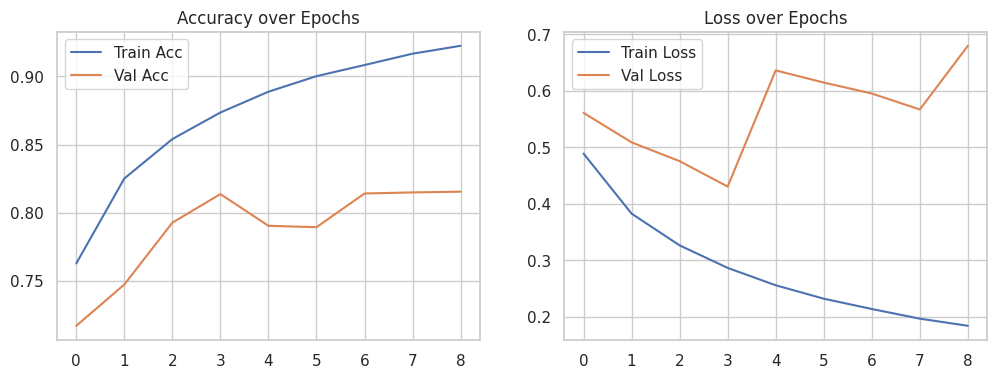

In [14]:
# Plot History
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.show()

# Model Evaluation

2528/2528 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.83      0.85     51240
           1       0.73      0.78      0.75     29630

    accuracy                           0.81     80870
   macro avg       0.80      0.80      0.80     80870
weighted avg       0.82      0.81      0.81     80870



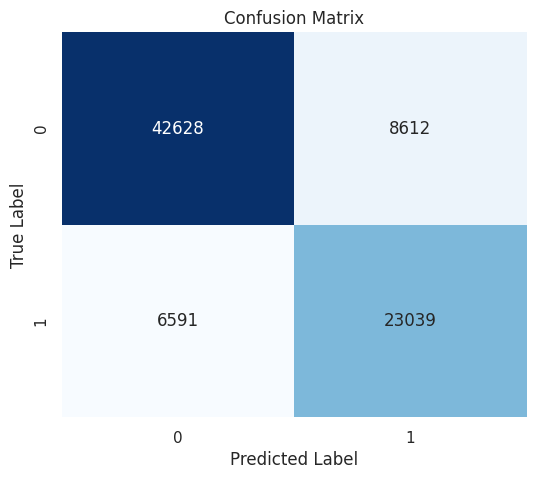

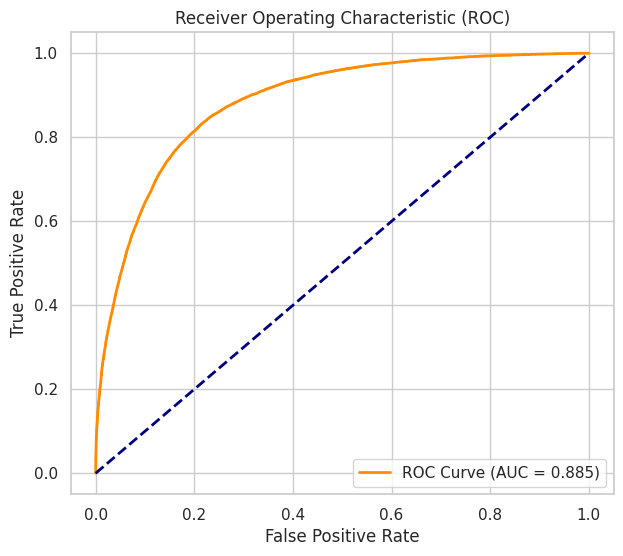

Final AUC Score: 0.8847


In [15]:
# Predict
y_pred_prob = model.predict([X_test_q1, X_test_q2])
y_pred = (y_pred_prob > 0.5).astype(int)

# 1. Classification Report (Precision, Recall, F1)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# 3. ROC-AUC Curve
auc_score = roc_auc_score(y_test, y_pred_prob)
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

print(f"Final AUC Score: {auc_score:.4f}")

# 1. Overall Performance Summary:

The model achieved an overall accuracy of 81% on the test set. The AUC-ROC score is 0.8847, which indicates good discriminatory power.

# 2. Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.83      0.85     51240
           1       0.73      0.78      0.75     29630

    accuracy                           0.81     80870

    macro avg       0.80      0.80     0.80     80870

    weighted avg    0.82      0.81     0.81     80870

**Class 0 (Non-Duplicate Questions):**

   **Precision:** 0.87 (When the model predicts a non-duplicate, it's
correct 87% of the time).

**Recall:** 0.83 (The model correctly identifies 83% of all actual non-duplicate pairs).

**F1-score:** 0.85 (Harmonic mean of precision and recall for non-duplicates).

**Class 1 (Duplicate Questions):**

**Precision:** 0.73 (When the model predicts a duplicate, it's correct 73% of the time).

**Recall:** 0.78 (The model correctly identifies 78% of all actual duplicate pairs).

**F1-score:** 0.75 (Harmonic mean of precision and recall for duplicates).

# 3. Confusion Matrix:

The confusion matrix visually demonstrates the classification results:

**Confusion Matrix plot showing True Label vs Predicted Label with values for 0 and 1.**

**True Negatives (Top-Left):** 42,628 non-duplicate pairs were correctly classified as non-duplicates.

**False Positives (Top-Right):** 8,612 non-duplicate pairs were incorrectly classified as duplicates.

**False Negatives (Bottom-Left):** 6,591 duplicate pairs were incorrectly classified as non-duplicates.

**True Positives (Bottom-Right):** 23,039 duplicate pairs were correctly classified as duplicates.

**4. ROC-AUC Curve:**

ROC Curve plot with False Positive Rate on x-axis and True Positive Rate on y-axis, showing an **AUC of 0.8847.**

The ROC-AUC curve illustrates the model's ability to distinguish between the two classes across various threshold settings. The AUC score of 0.8847 confirms the model's strong performance in ranking duplicate pairs higher than non-duplicate pairs.

***In summary, the model shows good performance in identifying duplicate questions, especially considering the inherent difficulty of the task. There's a slight imbalance in performance between the two classes, with higher precision for non-duplicates and slightly better recall for duplicates. This suggests a balance between avoiding false positives and not missing too many true duplicate***s.